<a href="https://colab.research.google.com/github/pedroabn/portfolio/blob/Geral/UNPairtplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os.path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files

In [ ]:
def idh(idh):
  if idh >= 0.8:
    return "Muito Alto"
  elif  0.700 <= idh < 0.799:
    return "Alto"
  elif 0.55 <= idh < 0.700:
    return "Médio"
  elif idh < 0.55:
    return "Baixo"

def converter(valor):
    valor = str(valor).lower()
    valor = valor.replace('$', '').strip()

    if 'billion' in valor:
        return float(valor.replace('billion', '').strip()) * 1000000000
    elif 'trillion' in valor:
        return float(valor.replace('trillion', '').strip()) * 1000000000000
    elif 'million' in valor:
        return float(valor.replace('million', '').strip()) * 1000000
    return float(valor)


In [ ]:
uploaded = files.upload()
df = pd.read_csv("dados.csv")

Saving empresasativender.csv to empresasativender.csv


FileNotFoundError: [Errno 2] No such file or directory: 'dados.csv'

In [ ]:
df2  = df.copy()
df2['IDH'] = (df['Human Development Index (HDI)']).apply(idh)
df2['IDH'].fillna('Desconhecido')
df2['GDP (in millions USD)'] = df2['Nominal Gross Domestic Product (in USD)'].apply(converter)
colunas_para_converter = ['Population (in millions)','Nominal Gross Domestic Product (in USD)',
    'Nominal GDP Per capita (in USD)','GDP Per capita PPP (in USD)','AREA (in Sq km)']
for coluna in colunas_para_converter:
    df2[coluna] = pd.to_numeric(df2[coluna].str.replace(',', ''), errors='coerce')

In [ ]:
print((df2['IDH'] == 'Muito Alto').sum())
print((df2['IDH'] == 'Alto').sum())
print((df2['IDH'] == 'Médio').sum())
print((df2['IDH'] == 'Baixo').sum())
print((df2['IDH'] == 'Desconhecido').sum())

NameError: name 'df2' is not defined

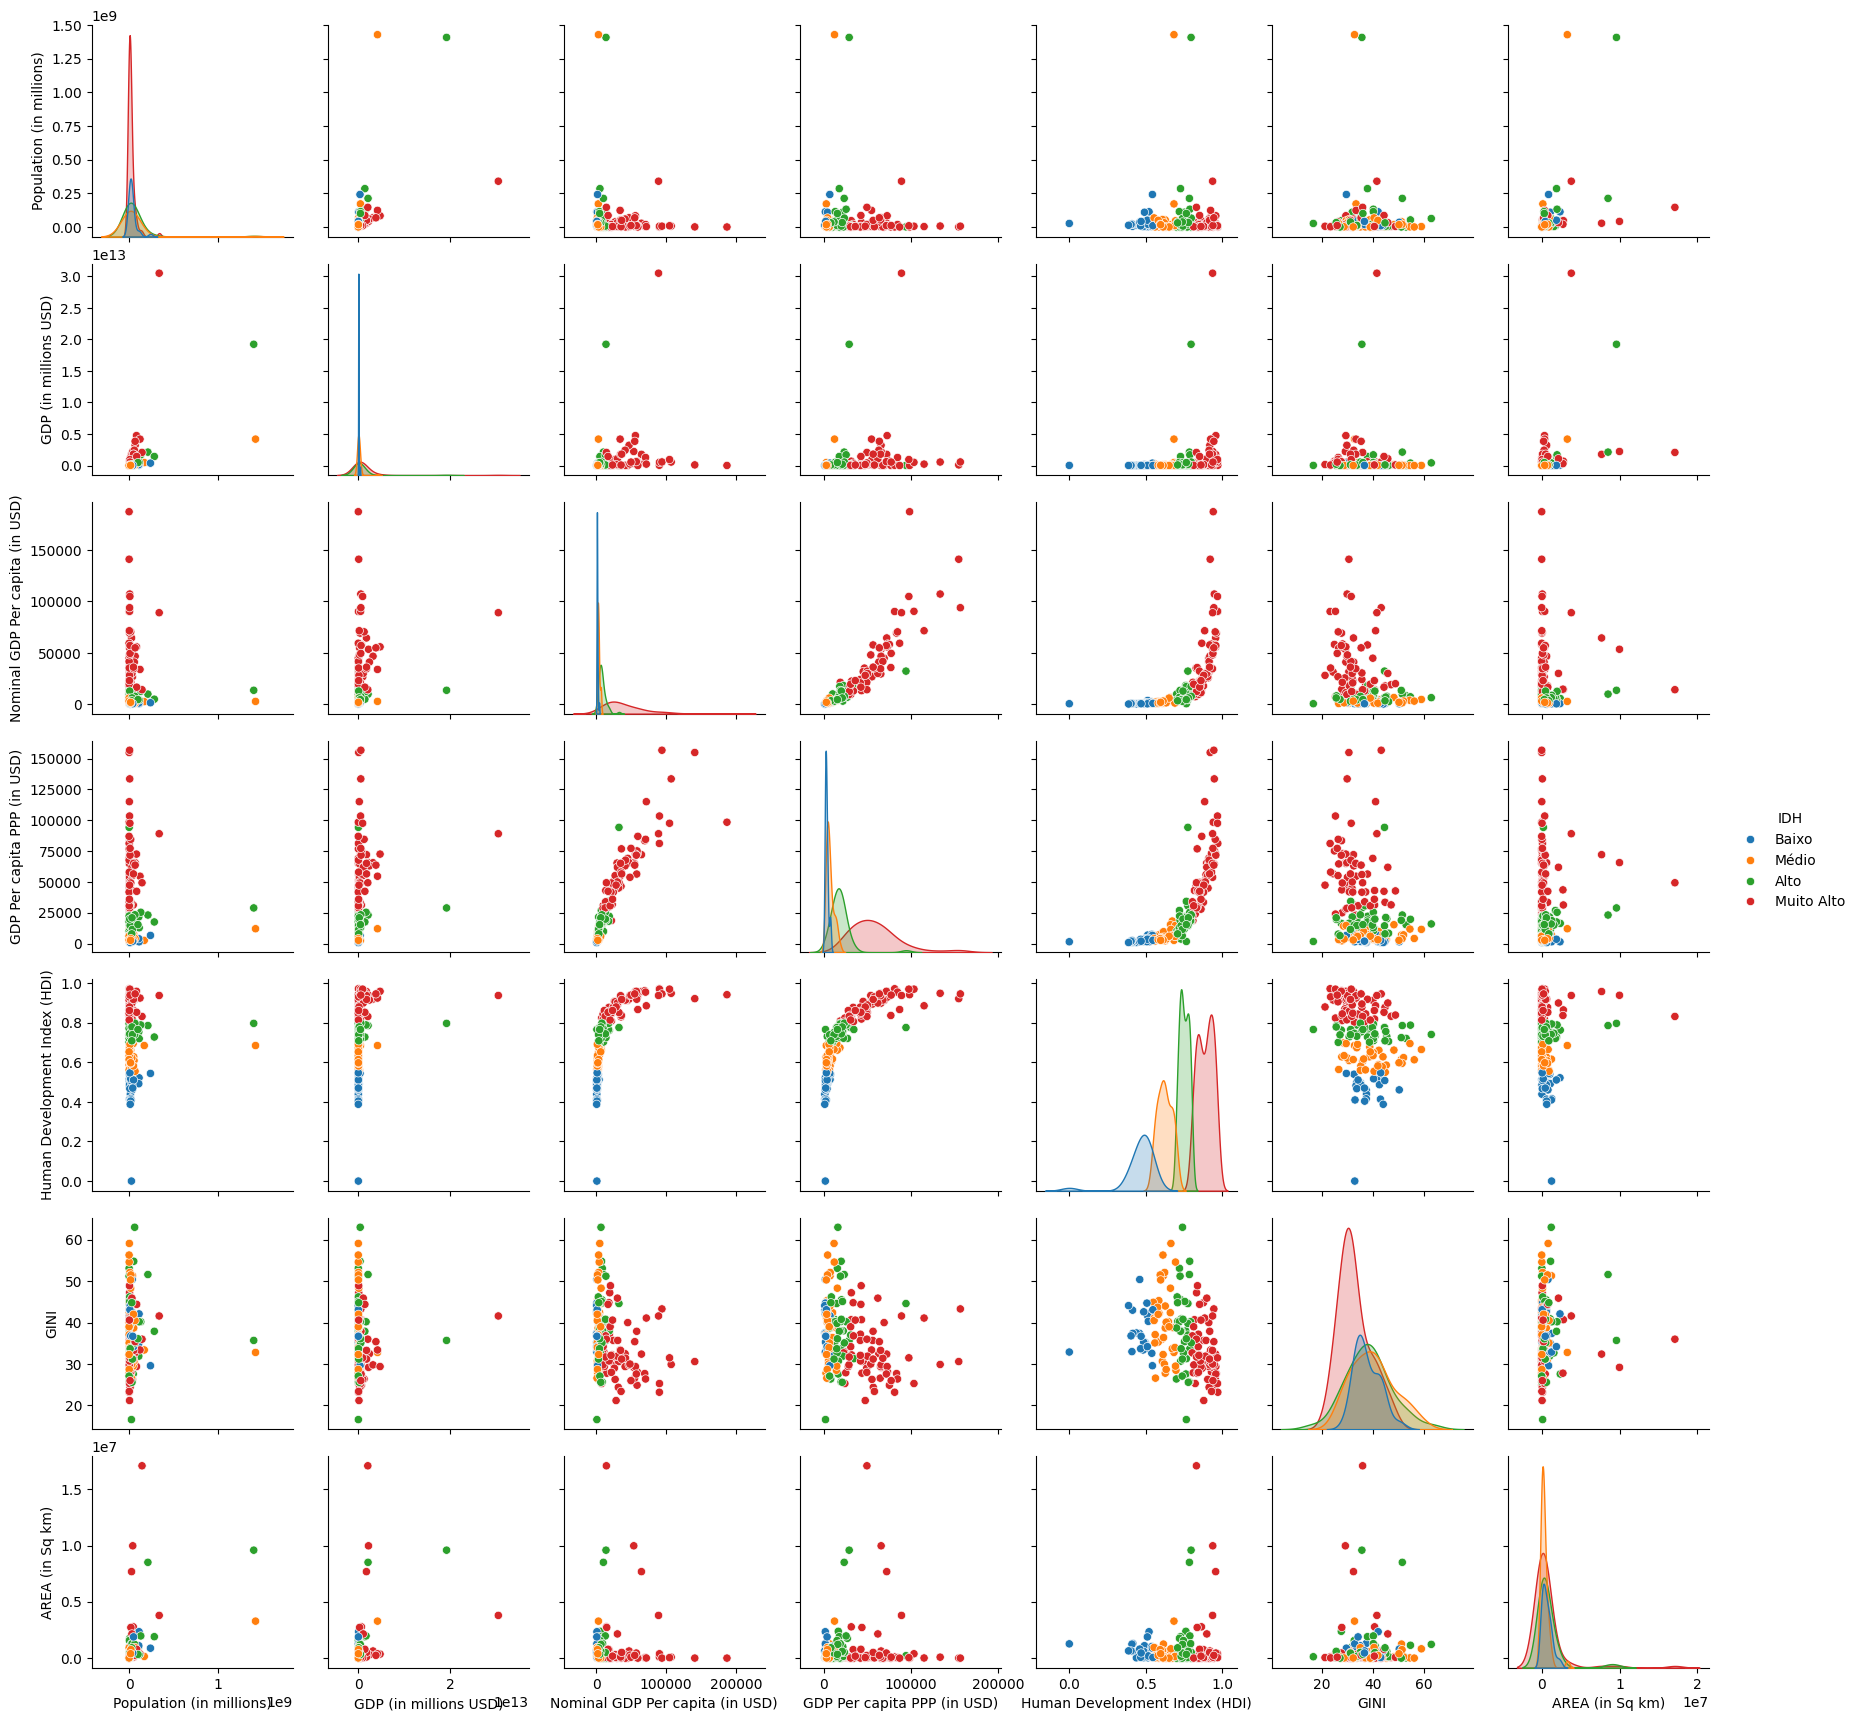

In [ ]:
ordem = ['Baixo', 'Médio', 'Alto', 'Muito Alto']
fig = sns.pairplot(df2[['Population (in millions)', 'IDH',
       'GDP (in millions USD)','Nominal GDP Per capita (in USD)', 'GDP Per capita PPP (in USD)',
       'Human Development Index (HDI)', 'GINI', 'AREA (in Sq km)']],
                   hue = 'IDH', hue_order = ordem)

In [ ]:
fig.savefig("grafico_pairplot.png")
files.download("grafico_pairplot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
resumo = df2.groupby("IDH")["Human Development Index (HDI)"].agg(['min', 'max']).reset_index()
print(resumo)


          IDH    min    max
0        Alto  0.701  0.798
1       Baixo  0.000  0.547
2  Muito Alto  0.804  0.972
3       Médio  0.550  0.698
